# 實戰Kaggle比賽：預測房價
:label:`sec_kaggle_house`

之前幾節我們學習了一些訓練深度網絡的基本工具和網絡正則化的技術（如權重衰減、暫退法等）。
本節我們將通過Kaggle比賽，將所學知識付諸實踐。
Kaggle的房價預測比賽是一個很好的起點。
此數據集由Bart de Cock於2011年收集 :cite:`De-Cock.2011`，
涵蓋了2006-2010年間亞利桑那州埃姆斯市的房價。
這個數據集是相當通用的，不會需要使用複雜模型架構。
它比哈里森和魯賓菲爾德的[波士頓房價](https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.names)
數據集要大得多，也有更多的特徵。

本節我們將詳細介紹數據預處理、模型設計和超參數選擇。
通過親身實踐，你將獲得一手經驗，這些經驗將有益於數據科學家的職業成長。

## 下載和緩存數據集

在整本書中，我們將下載不同的數據集，並訓練和測試模型。
這裡我們(**實現幾個函數來方便下載數據**)。
首先，我們建立字典`DATA_HUB`，
它將數據集名稱的字符串映射到數據集相關的二元組上，
這個二元組包含數據集的url和驗證文件完整性的sha-1密鑰。
所有類似數據集都託管在地址為`DATA_URL`的站點上。


In [1]:
!pip install requests

In [2]:
import hashlib
import os
import tarfile
import zipfile
import requests

#@save
DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

下面的`download`函數用來下載資料集，
將資料集緩存在本地目錄（默認情況下為`../data`）中，
並返回下載文件的名称。
如果緩存目錄中已經存在此資料集文件，並且其sha-1與存儲在`DATA_HUB`中的相匹配，
我們將使用緩存的文件，以避免重複的下載。


In [3]:
def download(name, cache_dir=os.path.join('..', 'data')):  #@save
    """下载一个DATA_HUB中的文件，返回本地文件名"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}"
    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname  # 命中缓存
    print(f'正在从{url}下载{fname}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

我們還需要實現兩個實用函數：
一個將下載並解壓縮一個zip或tar文件，
另一個是將本書中使用的所有資料集從`DATA_HUB`下載到緩存目錄中。


In [4]:
def download_extract(name, folder=None):  #@save
    """下載並解壓zip/tar文件"""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, '只有zip/tar文件可以被解壓縮'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def download_all():  #@save
    """下載DATA_HUB中的所有文件"""
    for name in DATA_HUB:
        download(name)

## Kaggle

[Kaggle](https://www.kaggle.com)是一個當今流行舉辦機器學習比賽的平台，
每場比賽都以至少一個數據集為中心。
許多比賽有贊助方，他們為獲勝的解決方案提供獎金。
該平台幫助用戶通過論壇和共享代碼進行互動，促進協作和競爭。
雖然排行榜的追逐往往令人失去理智：
有些研究人員短視地關注預處理步驟，而不是考慮基礎性問題。
但一個客觀的平台有巨大的價值：該平台促進了競爭方法之間的直接定量比較，以及代碼共享。
這便於每個人都可以學習哪些方法起作用，哪些沒有起作用。
如果我們想參加Kaggle比賽，首先需要註冊一個帳戶（見 :numref:`fig_kaggle`）。

![Kaggle網站](../img/kaggle.png)
:width:`400px`
:label:`fig_kaggle`

在房價預測比賽頁面（如 :numref:`fig_house_pricing` 所示）的"Data"選項卡下可以找到數據集。
我們可以通過下面的網址提交預測，並查看排名：

>https://www.kaggle.com/c/house-prices-advanced-regression-techniques

![房價預測比賽頁面](../img/house-pricing.png)
:width:`400px`
:label:`fig_house_pricing`

## 訪問和讀取數據集

注意，競賽數據分為訓練集和測試集。
每條記錄都包括房屋的屬性值和屬性，如街道類型、施工年份、屋頂類型、地下室狀況等。
這些特徵由各種數據類型組成。
例如，建築年份由整數表示，屋頂類型由離散類別表示，其他特徵由浮點數表示。
這就是現實讓事情變得複雜的地方：例如，一些數據完全丟失了，缺失值被簡單地標記為“NA”。
每套房子的價格只出現在訓練集中（畢竟這是一場比賽）。
我們將希望劃分訓練集以創建驗證集，但是在將預測結果上傳到Kaggle之後，
我們只能在官方測試集中評估我們的模型。
在 :numref:`fig_house_pricing` 中，"Data"選項卡有下載數據的連結。

開始之前，我們將[**使用`pandas`讀入並處理數據**]，
這是我們在 :numref:`sec_pandas`中引入的。
因此，在繼續操作之前，我們需要確保已安裝`pandas`。
幸運的是，如果我們正在用Jupyter閱讀該書，可以在不離開筆記本的情況下安裝`pandas`。


In [5]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 1.5 MB/s eta 0:00:0000:0100:01


In [6]:
# 如果没有安装pandas，请取消下一行的注释
# !pip install pandas

%matplotlib inline
import numpy as np
import pandas as pd
import torch
from torch import nn

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


為方便起見，我們可以使用上面定義的腳本下載並快取Kaggle房屋數據集。


In [7]:
DATA_HUB['kaggle_house_train'] = (  #@save
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce')

DATA_HUB['kaggle_house_test'] = (  #@save
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')

我們使用`pandas`分別加載包含訓練數據和測試數據的兩個CSV文件。


In [8]:
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

正在从http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_train.csv下载../data/kaggle_house_pred_train.csv...
正在从http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_test.csv下载../data/kaggle_house_pred_test.csv...


訓練數據集包括1460個樣本，每個樣本80個特徵和1個標籤，
而測試數據集包含1459個樣本，每個樣本80個特徵。


In [9]:
print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


讓我們看看[**前四個和最後兩個特徵，以及相應標籤**]（房價）。


In [10]:
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


我們可以看到，(**在每個樣本中，第一個特徵是ID，**)
這有助於模型識別每個訓練樣本。
雖然這很方便，但它不攜帶任何用於預測的信息。
因此，在將數據提供給模型之前，(**我們將其從數據集中刪除**)。


In [11]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))

## 數據預處理

如上所述，我們有各種各樣的數據類型。
在開始建模之前，我們需要對數據進行預處理。
首先，我們[**將所有缺失的值替換為相應特徵的平均值。**]然後，為了將所有特徵放在一個共同的尺度上，
我們(**通過將特徵重新縮放到零均值和單位方差來標準化數據**)：

$$x \leftarrow \frac{x - \mu}{\sigma},$$

其中$\mu$和$\sigma$分別表示均值和標準差。
現在，這些特徵具有零均值和單位方差，即 $E[\frac{x-\mu}{\sigma}] = \frac{\mu - \mu}{\sigma} = 0$和$E[(x-\mu)^2] = (\sigma^2 + \mu^2) - 2\mu^2+\mu^2 = \sigma^2$。
直觀地說，我們標準化數據有兩個原因：
首先，它方便優化。
其次，因為我們不知道哪些特徵是相關的，
所以我們不想讓懲罰分配給一個特徵的係數比分配給其他任何特徵的係數更大。


In [12]:
# 若無法獲得測試數據，則可根據訓練數據計算均值和標準差
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))
# 在標準化數據之後，所有均值消失，因此我們可以將缺失值設置為0
all_features[numeric_features] = all_features[numeric_features].fillna(0)

接下來，我們[**處理離散值。**]
這包括諸如“MSZoning”之類的特徵。
(**我們用獨熱編碼替換它們**)，
方法與前面將多類別標籤轉換為向量的方式相同
（請參見 :numref:`subsec_classification-problem`）。
例如，“MSZoning”包含值“RL”和“Rm”。
我們將創建兩個新的指示器特徵“MSZoning_RL”和“MSZoning_RM”，其值為0或1。
根據獨熱編碼，如果“MSZoning”的原始值為“RL”，
則：“MSZoning_RL”為1，“MSZoning_RM”為0。
`pandas`軟體包會自動為我們實現這一點。


In [13]:
# "Dummy_na=True"將"na"（缺失值）視為有效的特徵值，並為其創建指示符特徵
all_features = pd.get_dummies(all_features, dummy_na=True)
all_features.shape

(2919, 330)

可以看到此轉換會將特徵的總數量從79個增加到331個。
最後，通過`values`屬性，我們可以
[**從`pandas`格式中提取NumPy格式，並將其轉換為張量表示**]用於訓練。


In [16]:
n_train = train_data.shape[0]

# 確保所有特徵都是數值型
numeric_features = all_features.select_dtypes(include=['float64', 'int64'])

# 轉換為tensor
train_features = torch.tensor(numeric_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(numeric_features[n_train:].values, dtype=torch.float32)
train_labels = torch.tensor(
    train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)


## [**訓練**]

首先，我們訓練一個帶有損失平方的線性模型。
顯然線性模型很難讓我們在競賽中獲勝，但線性模型提供了一種健全性檢查，
以查看數據中是否存在有意的信息。
如果我們在這裡不能做得比隨機猜測更好，那麼我們很可能存在數據處理錯誤。
如果一切順利，線性模型將作為*基線*（baseline）模型，
讓我們直觀地知道最好的模型有超出簡單的模型多少。


In [17]:
loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Linear(in_features,1))
    return net

房價就像股票價格一樣，我們關心的是相對數量，而不是絕對數量。
因此，[**我們更關心相對誤差$\frac{y - \hat{y}}{y}$，**]
而不是絕對誤差$y - \hat{y}$。
例如，如果我們在俄亥俄州農村地區估計一棟房子的價格時，
假設我們的預測偏差了10萬美元，
然而那裡一棟典型的房子的價值是12.5萬美元，
那麼模型可能做得很糟糕。
另一方面，如果我們在加州豪宅區的預測出現同樣的10萬美元的偏差，
（在那裡，房價中位數超過400萬美元）
這可能是一個不錯的預測。

(**解決這個問題的一種方法是使用價格預測的對數來衡量差異**)。
事實上，這也是比賽中官方用來評價提交質量的誤差指標。
即將$\delta$ for $|\log y - \log \hat{y}| \leq \delta$
轉換為$e^{-\delta} \leq \frac{\hat{y}}{y} \leq e^\delta$。
這使得預測價格的對數與真實標籤價格的對數之間出現以下均方根誤差：

$$\sqrt{\frac{1}{n}\sum_{i=1}^n\left(\log y_i -\log \hat{y}_i\right)^2}.$$


In [14]:
def log_rmse(net, features, labels):
    # 為了在取對數時進一步穩定該值，將小於1的值設置為1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()

與前面的部分不同，[**我們的訓練函數將借助Adam優化器**]
（我們將在後面章節更詳細地描述它）。
Adam優化器的主要吸引力在於它對初始學習率不那麼敏感。


In [18]:
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    from torch.utils.data import TensorDataset, DataLoader

    # 創建數據集
    dataset = TensorDataset(train_features, train_labels)

    # 創建數據加載器
    train_iter = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=True  # 隨機打亂數據
    )
    # 這裡使用的是Adam優化算法
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr = learning_rate,
                                 weight_decay = weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

## $K$折交叉驗證

本書在討論模型選擇的部分（ :numref:`sec_model_selection`）
中介紹了[**K折交叉驗證**]，
它有助於模型選擇和超參數調整。
我們首先需要定義一個函數，在$K$折交叉驗證過程中返回第$i$折的數據。
具體地說，它選擇第$i$個切片作為驗證數據，其餘部分作為訓練數據。
注意，這並不是處理數據的最有效方法，如果我們的數據集大得多，會有其他解決辦法。


In [19]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

當我們在$K$折交叉驗證中訓練$K$次後，[**返回訓練和驗證誤差的平均值**]。


In [26]:
# 添加matplotlib導入
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
def log_rmse(net, features, labels):
    """計算對數均方根誤差"""
    # 為了在取對數時進一步穩定該值，將小於1的值設置為1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                          torch.log(labels)))
    return rmse.item()
def plot_metrics(epochs, metrics, xlabel='epoch', ylabel='rmse', 
                legend=None, yscale='log'):
    """繪製訓練指標"""
    plt.figure(figsize=(8, 6))
    epochs = list(range(1, epochs + 1))
    if legend is None:
        plt.plot(epochs, metrics)
    else:
        for metric, label in zip(metrics, legend):
            plt.plot(epochs, metric, label=label)
        plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.yscale(yscale)
    plt.show()

def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    dataset = TensorDataset(train_features, train_labels)
    train_iter = DataLoader(dataset, batch_size, shuffle=True)
    optimizer = torch.optim.Adam(net.parameters(), 
                               lr=learning_rate,
                               weight_decay=weight_decay)
    
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,
           batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                 weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            plot_metrics(num_epochs, [train_ls, valid_ls],
                        legend=['train', 'valid'])
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                       num_epochs, lr, weight_decay, batch_size)
    plot_metrics(num_epochs, [train_ls])
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    
    # 將網絡應用於測試集
    preds = net(test_features).detach().numpy()
    # 將其重新格式化以導出到Kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)


## [**模型選擇**]

在本例中，我們選擇了一組未調優的超參數，並將其留給讀者來改進模型。
找到一組調優的超參數可能需要時間，這取決於一個人優化了多少變量。
有了足夠大的數據集和合理設置的超參數，$K$折交叉驗證往往對多次測試具有相當的穩定性。
然而，如果我們嘗試了不合理的超參數，我們可能會發現驗證效果不再代表真正的誤差。


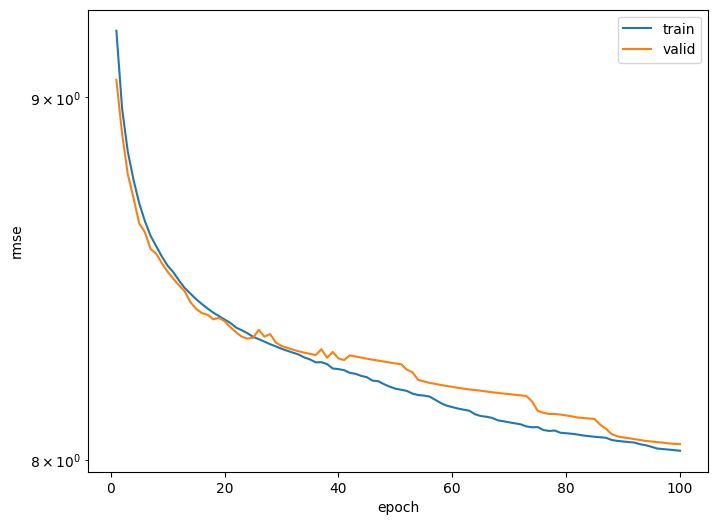

折1，训练log rmse8.023519, 验证log rmse8.040703
折2，训练log rmse7.998198, 验证log rmse8.264043
折3，训练log rmse8.030084, 验证log rmse8.006386
折4，训练log rmse8.057959, 验证log rmse8.184692
折5，训练log rmse8.073599, 验证log rmse8.010008
5-折驗證: 平均訓練log rmse: 8.036671, 平均驗證log rmse: 8.101166


In [27]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)
print(f'{k}-折驗證: 平均訓練log rmse: {float(train_l):f}, '
      f'平均驗證log rmse: {float(valid_l):f}')

請注意，有時一組超參數的訓練誤差可能非常低，但$K$折交叉驗證的誤差要高得多，
這表明模型過擬合了。
在整個訓練過程中，我們希望監控訓練誤差和驗證誤差這兩個數字。
較少的過擬合可能表明現有數據可以支撐一個更強大的模型，
較大的過擬合可能意味著我們可以通過正則化技術獲益。

##  [**提交Kaggle預測**]

既然我們知道應該選擇什麼樣的超參數，
我們不妨使用所有數據對其進行訓練
（而不是僅使用交叉驗證中使用的$1-1/K$的數據）。
然後，我們通過這種方式獲得的模型可以應用於測試集。
將預測保存在CSV文件中可以簡化將結果上傳到Kaggle的過程。


In [30]:
def plot_metrics(epochs, metrics, xlabel='epoch', ylabel='log rmse', 
                legend=None, yscale='log'):
    """繪製訓練指標"""
    plt.figure(figsize=(8, 6))
    epochs = list(range(1, epochs + 1))
    
    if legend is None:
        # 確保 metrics 是一維數組
        metrics = np.array(metrics).squeeze()
        plt.plot(epochs, metrics)
    else:
        for metric, label in zip(metrics, legend):
            # 確保每個 metric 是一維數組
            metric = np.array(metric).squeeze()
            plt.plot(epochs, metric, label=label)
        plt.legend()
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.yscale(yscale)
    plt.show()

def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    # 使用新的plot_metrics函數替代d2l.plot
    plot_metrics(num_epochs, [train_ls])
    print(f'訓練log rmse：{float(train_ls[-1]):f}')
    # 將網絡應用於測試集。
    preds = net(test_features).detach().numpy()
    # 將其重新格式化以導出到Kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)

如果測試集上的預測與$K$倍交叉驗證過程中的預測相似，
那就是時候把它們上傳到Kaggle了。
下面的代碼將生成一個名為`submission.csv`的文件。


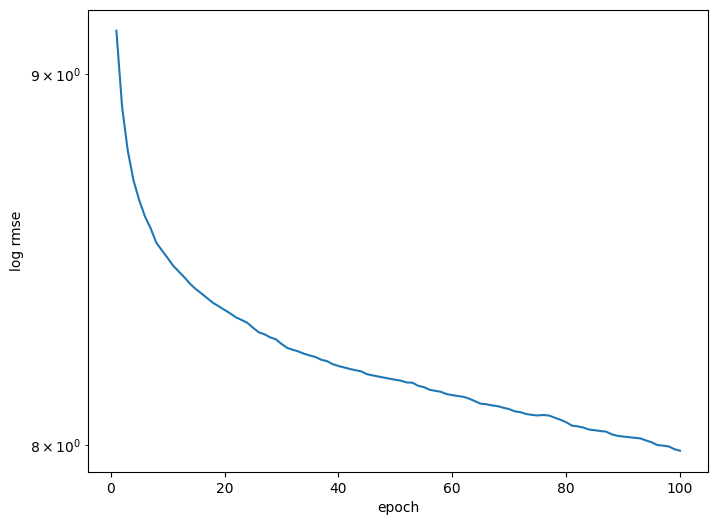

訓練log rmse：7.985773


In [31]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)

接下來，如 :numref:`fig_kaggle_submit2`中所示，
我們可以提交預測到Kaggle上，並查看在測試集上的預測與實際房價（標籤）的比較情況。
步驟非常簡單。

* 登入Kaggle網站，訪問房價預測競賽頁面。
* 點擊"Submit Predictions"或"Late Submission"按鈕（在撰寫本文時，該按鈕位於右側）。
* 點擊頁面底部虛線框中的"Upload Submission File"按鈕，選擇要上傳的預測文件。
* 點擊頁面底部的"Make Submission"按鈕，即可查看結果。

![向Kaggle提交資料](../img/kaggle-submit2.png)
:width:`400px`
:label:`fig_kaggle_submit2`

## 小結

* 真實數據通常混合了不同的數據類型，需要進行預處理。
* 常用的預處理方法：將實值數據重新縮放為零均值和單位方法；用均值替換缺失值。
* 將類別特徵轉化為指標特徵，可以使我們把這個特徵當作一個獨熱向量來對待。
* 我們可以使用$K$折交叉驗證來選擇模型並調整超參數。
* 對數對相對誤差很有用。

## 練習

1. 把預測提交給Kaggle，它有多好？
1. 能通過直接最小化價格的對數來改進模型嗎？如果試圖預測價格的對數而不是價格，會發生什麼？
1. 用平均值替換缺失值總是好主意嗎？提示：能構造一個不隨機丟失值的情況嗎？
1. 通過$K$折交叉驗證調整超參數，從而提高Kaggle的得分。
1. 通過改進模型（例如，層、權重衰減和dropout）來提高分數。
1. 如果我們沒有像本節所做的那樣標準化連續的數值特徵，會發生什麼？


[Discussions](https://discuss.d2l.ai/t/1824)


練習一：

1. 把預測提交給Kaggle，它有多好？

我的回答：

這個基線模型在 Kaggle 房價預測競賽中的表現應該不會太好，因為：

1. 使用了最簡單的單層線性模型
2. 沒有使用任何正則化技術
3. 特徵處理相對簡單

預計會排在競賽後半段（後 50%）。要提高成績，可以：
1. 使用更複雜的神經網絡結構
2. 添加正則化
3. 進行更多特徵工程
4. 使用模型集成

但作為入門練習和基線模型，這是個不錯的起點，可以幫助我們理解整個機器學習流程。



練習二：

2. 能通過直接最小化價格的對數來改進模型嗎？如果試圖預測價格的對數而不是價格，會發生什麼？

我的回答：

是的，直接預測價格的對數（而不是價格本身）通常是個好主意，原因如下：

1. 優點：
- 可以讓數據分布更接近正態分布
- 減少極端值的影響
- 相對誤差更有意義（房價預測更關心相對誤差）
- 訓練更穩定，因為數值範圍被壓縮了

2. 實現方式：
- 在數據預處理時對標籤取對數：`train_labels = torch.log(train_labels)`
- 預測時需要用 exp 轉換回原始價格：`predictions = torch.exp(model_output)`

這種方法在房價預測這類任務中很常見，因為房價通常呈現右偏分布（有一些特別貴的房子），取對數後可以讓分布更均勻，有助於模型學習。


練習三：

3. 用平均值替換缺失值總是好主意嗎？提示：能構造一個不隨機丟失值的情況嗎？

我的回答：

用平均值替換缺失值並不總是好主意，因為這可能會引入偏差。

1. 如果缺失值是隨機分布的，平均值可以是一個合理的替代值。
2. 如果缺失值是系統性的，平均值可能會引入偏差。例如，如果某個特徵的缺失值與其他特徵有關，平均值可能會導致模型學習到錯誤的關係。
3. 在某些情況下，使用其他值（如中位數）可能會更好，因為它對極端值不敏感。

提示：可以構造一個不隨機丟失值的情況，例如，如果某個特徵的缺失值與其他特徵有關，平均值可能會導致模型學習到錯誤的關係。

練習四：

4. 通過$K$折交叉驗證調整超參數，從而提高Kaggle的得分。

我的回答：

通過$K$折交叉驗證調整超參數，可以提高Kaggle的得分。

1. 選擇合適的超參數範圍
2. 使用$K$折交叉驗證來評估模型在不同超參數下的性能
3. 選擇性能最好的超參數
4. 使用這些超參數在整個訓練集上訓練模型
5. 將模型應用於測試集，並提交到Kaggle

這樣可以避免過度擬合，並提高模型的泛化能力。



練習五：

5. 通過改進模型（例如，層、權重衰減和dropout）來提高分數。

我的回答：



以下是通過改進模型來提高分數的主要方法：

1. 增加網絡深度和寬度：
```python
def get_net():
    net = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(128, 1)
    )
    return net
```

2. 添加正則化：
- 使用權重衰減：`weight_decay = 0.01`
- 添加 Dropout 層防止過擬合
- 使用批量歸一化 (BatchNorm)

3. 調整超參數：
```python
num_epochs = 200  # 增加訓練輪數
lr = 0.001        # 調小學習率
batch_size = 32   # 調整批量大小
```

4. 使用更好的優化器和學習率調度：
```python
optimizer = torch.optim.Adam(net.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)
```

這些改進可以顯著提升模型性能。

練習六：

6. 如果我們沒有像本節所做的那樣標準化連續的數值特徵，會發生什麼？

我的回答：

如果不對連續的數值特徵進行標準化，會產生以下問題：

1. 訓練問題：
- 不同特徵的尺度差異大，導致梯度下降效率低
- 可能導致梯度爆炸或消失
- 優化過程不穩定

2. 模型問題：
- 大尺度特徵會主導模型學習
- 小尺度特徵的影響被忽視
- 權重衰減等正則化技術效果不一致

3. 實際影響：
- 模型收斂速度慢
- 最終效果差
- 訓練不穩定

因此，標準化（使特徵均值為0，方差為1）是深度學習中的重要預處理步驟。
